# L'ACP

## 1.1 Context

Nous réalisons une ACP dans le but de regrouper les indicateurs PESTEL dans des varaiables synthétiques afin de trouver les pays les plus intéressants pour nous. 

## 1.2 Imports

Nous allons importer nos librairies :

In [2183]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 1.3 Graphics and Options

On 'charge' `seaborn` :

In [2184]:
sns.set()

On crée nos fonctions pour afficher les cercle des correlations et le nuage d'individus sur les plans factoriels.

In [2185]:
def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

In [2186]:
def display_factorial_planes(
    X_projected,
    x_y,
    pca=None,
    labels=None,
    clusters=None,
    alpha=1,
    figsize=(10, 8),
    marker=".",
    s=30,
    centroids=None,
    centroids_marker="p",
):
    """Affiche la projection des individus sur les plans factoriels avec légendes séparées."""
    X_ = np.array(X_projected)

    if len(x_y) != 2:
        raise AttributeError(
            "Le paramètre x_y doit contenir exactement 2 axes (ex: [0, 1])."
        )
    if max(x_y) >= X_.shape[1]:
        raise AttributeError(
            "Les indices d'axes dépassent le nombre de dimensions disponibles."
        )

    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # 1. Affichage des points (Individus)
    sns.scatterplot(
        x=X_[:, x],
        y=X_[:, y],
        hue=clusters,
        palette="Set1",
        alpha=alpha,
        s=s,
        marker=marker,
        ax=ax,
    )
    # On capture les éléments de la légende des individus
    handles_ind, labels_ind = ax.get_legend_handles_labels()

    # 2. Affichage des centroïdes (si fournis)
    if centroids is not None:
        C_ = np.array(centroids)
        sns.scatterplot(
            x=C_[:, x],
            y=C_[:, y],
            marker=centroids_marker,
            s=s * 5,
            palette="Set1",  # Une palette différente pour bien les distinguer
            edgecolor="black",
            linewidth=1.5,
            zorder=5,
            hue=range(0, C_.shape[0]),  # Correction ici : C_ au lieu de centroids
            ax=ax,  # Correction ici : ajout de ax=ax
        )
        # On capture tous les éléments de la légende accumulés sur l'axe
        handles_all, labels_all = ax.get_legend_handles_labels()

        # On isole uniquement les éléments des centroïdes (ceux ajoutés après les individus)
        handles_cent = handles_all[len(handles_ind) :]
        labels_cent = labels_all[len(labels_ind) :]

    # Calcul du % de variance si l'objet PCA est fourni
    v1, v2 = "", ""
    if pca is not None:
        v1 = f" ({round(100 * pca.explained_variance_ratio_[x])} %)"
        v2 = f" ({round(100 * pca.explained_variance_ratio_[y])} %)"

    ax.set_xlabel(f"F{x+1}{v1}")
    ax.set_ylabel(f"F{y+1}{v2}")

    # Gestion des limites des axes (centrés sur 0)
    x_max = np.abs(X_[:, x]).max() * 1.1
    y_max = np.abs(X_[:, y]).max() * 1.1
    ax.set_xlim(-x_max, x_max)
    ax.set_ylim(-y_max, y_max)

    # Lignes du repère (origine)
    ax.axhline(0, color="grey", alpha=0.5, linestyle="--")
    ax.axvline(0, color="grey", alpha=0.5, linestyle="--")

    # Affichage des labels textuels si présents
    if labels is not None and len(labels) == len(X_):
        for i, (_x, _y) in enumerate(X_[:, [x, y]]):
            ax.text(
                _x,
                _y + (y_max * 0.02),
                str(labels[i]),
                fontsize=10,
                ha="center",
                va="center",
            )

    ax.set_title(f"Projection des individus (sur F{x+1} et F{y+1})")

    # 3. Gestion de la double légende
    if clusters is not None:
        # On crée la première légende (Individus) en haut à droite
        leg1 = ax.legend(
            handles_ind, labels_ind, title="Clusters", loc="upper right"
        )
        if centroids is not None:
            # S'il y a des centroïdes, on "fige" la première légende
            ax.add_artist(leg1)
            # Puis on crée la deuxième légende (Centroïdes) en bas à droite
            ax.legend(
                handles_cent,
                labels_cent,
                title="Centroïdes",
                loc="lower right",
            )
    elif centroids is not None:
        # Si pas de clusters mais des centroïdes, on affiche juste la légende des centroïdes
        ax.legend(handles_cent, labels_cent, title="Centroïdes", loc="upper right")

    plt.show()

## 1.4 Data

Nous allons maintenant charger les données.

Importons notre fichier. Faisons attentions aux options comme `decimal` ou `index_col` :

In [2187]:
df = pd.read_csv("df_final_2023.csv", decimal=".", index_col=0)
df.head()

,population,IDH,PIB_par_habitant,import_kg_poulet_par_habitant,Politic_score,Access_Elec_Pct,LPI,consommation_kg_poulet_par_habitant,dist,Continent
Pays,,,,,,,,,,
Afghanistan,41454761.0,0.496,396.015997,0.116060,2.485,85.3,1.9,0.794525,5590.3810,Asia
Afrique du Sud,63212384.0,0.741,5976.385851,4.949222,0.298,87.7,3.7,33.579152,9353.5520,Africa
Albanie,2811655.0,0.810,8172.294966,17.048237,-0.622,100.0,2.5,22.997046,1603.5340,Europe
Algérie,46164219.0,0.763,5364.027937,0.000608,-1.563,100.0,2.5,9.122530,1340.3900,Africa
Allemagne,84548231.0,0.959,53528.073268,5.830301,0.004,100.0,4.1,11.120669,439.8984,Europe


# 2 Data Preparation

## 2.1 Data Split

Nous allons ensuite séparer nos données. D'un coté `X` la matrice des données :

In [2188]:
df_x = df.drop(columns='Continent')

In [2189]:
X = df_x.values
X[:5]

array([[ 4.14547610e+07,  4.96000000e-01,  3.96015997e+02,
         1.16060493e-01,  2.48500000e+00,  8.53000000e+01,
         1.90000000e+00,  7.94524663e-01,  5.59038100e+03],
       [ 6.32123840e+07,  7.41000000e-01,  5.97638585e+03,
         4.94922229e+00,  2.98000000e-01,  8.77000000e+01,
         3.70000000e+00,  3.35791525e+01,  9.35355200e+03],
       [ 2.81165500e+06,  8.10000000e-01,  8.17229497e+03,
         1.70482367e+01, -6.22000000e-01,  1.00000000e+02,
         2.50000000e+00,  2.29970462e+01,  1.60353400e+03],
       [ 4.61642190e+07,  7.63000000e-01,  5.36402794e+03,
         6.07830060e-04, -1.56300000e+00,  1.00000000e+02,
         2.50000000e+00,  9.12253016e+00,  1.34039000e+03],
       [ 8.45482310e+07,  9.59000000e-01,  5.35280733e+04,
         5.83030105e+00,  4.00000000e-03,  1.00000000e+02,
         4.10000000e+00,  1.11206691e+01,  4.39898400e+02]])

C'est bien un `np.array` :

In [2190]:
type(X)

numpy.ndarray

La forme de cette matrice est conforme à nos attentes :

In [2191]:
X.shape

(143, 9)

Nous enregistrons les noms de nos Pays dans une variable `names` :

In [2192]:
names = df_x.index
names

Index(['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne',
       'Angola', 'Arabie Saoudite', 'Argentine', 'Arménie', 'Australie',
       ...
       'Viet Nam', 'Yémen', 'Zambie', 'Zimbabwe', 'Égypte',
       'Émirats arabes unis', 'Équateur', 'États-Unis d'Amérique', 'Éthiopie',
       'Îles Salomon'],
      dtype='object', name='Pays', length=143)

et nos colonnes, nos features, dans une variable `features` :

In [2193]:
features = df_x.columns
features

Index(['population', 'IDH', 'PIB_par_habitant',
       'import_kg_poulet_par_habitant', 'Politic_score', 'Access_Elec_Pct',
       'LPI', 'consommation_kg_poulet_par_habitant', 'dist'],
      dtype='object')

In [2194]:
continents = df['Continent']

# 3 About PCA

Nous pouvons - *enfin* - commencer notre ACP, ou notre PCA !

## 3.1 Scaling

Commençons par scaler les données. On instancie :

In [2195]:
scaler = StandardScaler()

On transforme et on fit :

In [2196]:
X_scaled = scaler.fit_transform(X)

On espère avoir une moyenne à 0 et un écart type à 1 :

In [2197]:
idx = ["mean", "std"]

pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7,8
mean,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


C'est parfait

## 3.2 Explained variance & scree plot

Nous allons travailler sur 8 composantes et voir quelle est le meilleur choix sur l'éboulis de valeur propre grâce à la méthode du coude.

In [2198]:
n_components = 8

On instancie notre ACP :

In [2199]:
pca = PCA(n_components=n_components)

On l'entraine sur les données scalées :

In [2200]:
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",8
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

Intéressons nous maintenant à la variance *captée* par chaque nouvelle composante. Grace à `scikit-learn` on peut utiliser l'attribut `explained_variance_ratio_` :

In [2201]:
pca.explained_variance_ratio_

array([0.39170518, 0.15335322, 0.12812435, 0.10999045, 0.08505958,
       0.0597799 , 0.03958739, 0.02397355])

Ici la 1ère composante *capte* 47% de la variance de nos données initiales, la 2ème 16% etc etc.

Enregistrons cela dans une variable :

In [2202]:
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([39.17, 15.34, 12.81, 11.  ,  8.51,  5.98,  3.96,  2.4 ])

Les 2 premières composantes *captent* donc '36 + 25 = 55%` de la variance.

In [2203]:
scree_cum = scree.cumsum().round()
scree_cum

array([39., 55., 67., 78., 87., 93., 97., 99.])

Définisons ensuite une variable avec la liste de nos composantes :

In [2204]:
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6, 7, 8]

On peut enfin l'afficher de façon graphique :

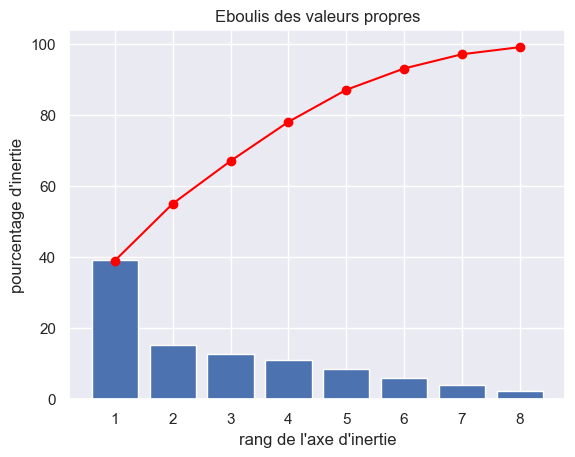

In [2205]:
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.show(block=False)

On voit ici que plus de 80% de la variance est comprise dans les 4 premières composantes.

## 3.4 Components

Intéressons nous maintenant à nos fameuses composantes.

In [2206]:
pcs = pca.components_
pcs

array([[-0.02395379,  0.50595167,  0.44109795,  0.23038794, -0.15943239,
         0.37716111,  0.44441909,  0.28681226, -0.2198962 ],
       [ 0.38867881,  0.12779242, -0.18658802, -0.30940443,  0.49973804,
         0.37282641, -0.00788498,  0.42313646,  0.36634329],
       [ 0.65906263,  0.0024999 ,  0.15479677, -0.34024197,  0.02917379,
        -0.06341514,  0.28724135, -0.49457016, -0.3064698 ],
       [ 0.23376922, -0.03265058,  0.09760097, -0.10684652, -0.66154582,
        -0.11383633,  0.15401927,  0.06730067,  0.66670148],
       [ 0.51470323, -0.11101067, -0.17455523,  0.82519814,  0.06546807,
        -0.06062856, -0.03363172,  0.03612315,  0.03062419],
       [ 0.04656277,  0.10260078, -0.40779531, -0.01560446, -0.40759134,
         0.67853155, -0.32247018, -0.26502253, -0.14143816],
       [ 0.28410187, -0.09125182,  0.04884913, -0.19436094, -0.31621053,
        -0.21311709, -0.3806772 ,  0.60315826, -0.46548234],
       [ 0.08009334, -0.15005198,  0.72980048,  0.07054872,  0

In [2207]:
type(pcs)

numpy.ndarray

Affichons la même chose mais version `pandas` :

In [2208]:
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8
0,-0.023954,0.505952,0.441098,0.230388,-0.159432,0.377161,0.444419,0.286812,-0.219896
1,0.388679,0.127792,-0.186588,-0.309404,0.499738,0.372826,-0.007885,0.423136,0.366343
2,0.659063,0.002500,0.154797,-0.340242,0.029174,-0.063415,0.287241,-0.494570,-0.306470
3,0.233769,-0.032651,0.097601,-0.106847,-0.661546,-0.113836,0.154019,0.067301,0.666701
4,0.514703,-0.111011,-0.174555,0.825198,0.065468,-0.060629,-0.033632,0.036123,0.030624
5,0.046563,0.102601,-0.407795,-0.015604,-0.407591,0.678532,-0.322470,-0.265023,-0.141438
6,0.284102,-0.091252,0.048849,-0.194361,-0.316211,-0.213117,-0.380677,0.603158,-0.465482
7,0.080093,-0.150052,0.729800,0.070549,0.119563,0.237973,-0.552577,-0.165530,0.172671


Ajoutons les labels de nos colonnes

In [2209]:
pcs.columns = features
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,population,IDH,PIB_par_habitant,import_kg_poulet_par_habitant,Politic_score,Access_Elec_Pct,LPI,consommation_kg_poulet_par_habitant,dist
F1,-0.02,0.51,0.44,0.23,-0.16,0.38,0.44,0.29,-0.22
F2,0.39,0.13,-0.19,-0.31,0.50,0.37,-0.01,0.42,0.37
F3,0.66,0.00,0.15,-0.34,0.03,-0.06,0.29,-0.49,-0.31
F4,0.23,-0.03,0.10,-0.11,-0.66,-0.11,0.15,0.07,0.67
F5,0.51,-0.11,-0.17,0.83,0.07,-0.06,-0.03,0.04,0.03
F6,0.05,0.10,-0.41,-0.02,-0.41,0.68,-0.32,-0.27,-0.14
F7,0.28,-0.09,0.05,-0.19,-0.32,-0.21,-0.38,0.60,-0.47
F8,0.08,-0.15,0.73,0.07,0.12,0.24,-0.55,-0.17,0.17



Transposons le Dataframe pour avoir les composantes en colonnes et nos variables comme des individus.

In [2210]:
pcs.T

,F1,F2,F3,F4,F5,F6,F7,F8
population,-0.023954,0.388679,0.659063,0.233769,0.514703,0.046563,0.284102,0.080093
IDH,0.505952,0.127792,0.002500,-0.032651,-0.111011,0.102601,-0.091252,-0.150052
PIB_par_habitant,0.441098,-0.186588,0.154797,0.097601,-0.174555,-0.407795,0.048849,0.729800
import_kg_poulet_par_habitant,0.230388,-0.309404,-0.340242,-0.106847,0.825198,-0.015604,-0.194361,0.070549
Politic_score,-0.159432,0.499738,0.029174,-0.661546,0.065468,-0.407591,-0.316211,0.119563
Access_Elec_Pct,0.377161,0.372826,-0.063415,-0.113836,-0.060629,0.678532,-0.213117,0.237973
LPI,0.444419,-0.007885,0.287241,0.154019,-0.033632,-0.322470,-0.380677,-0.552577
consommation_kg_poulet_par_habitant,0.286812,0.423136,-0.494570,0.067301,0.036123,-0.265023,0.603158,-0.165530
dist,-0.219896,0.366343,-0.306470,0.666701,0.030624,-0.141438,-0.465482,0.172671


Et pour une représentation plus *visuelle*, comme cela :

<Axes: >

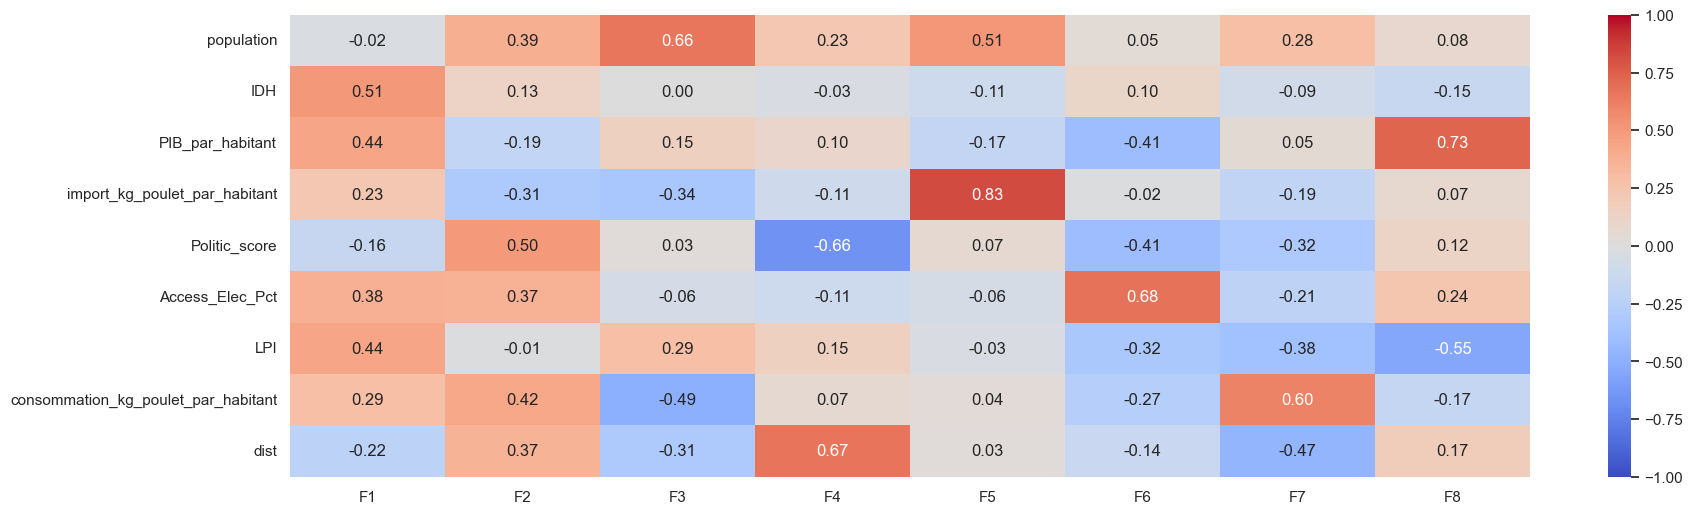

In [2211]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

## 3.5 Correlation graph

Définissons nos axes x et y. Nous allons utiliser les 2 premières composantes. Comme - en code - on commence à compter à partir de 0, cela nous donne :

Essayons cette fonction pour F1 et F2

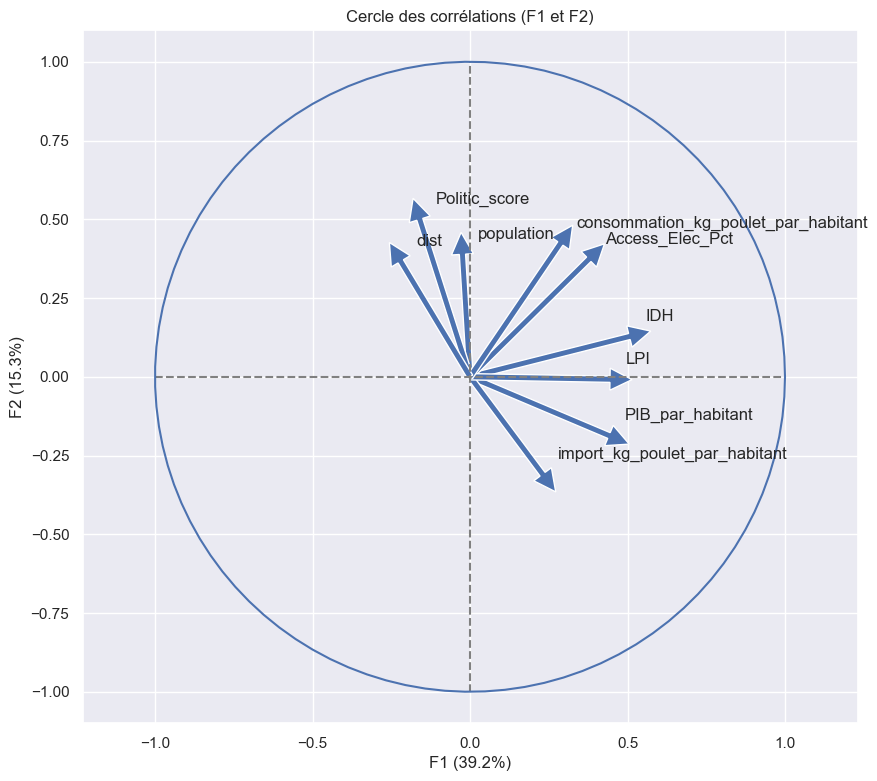

In [2212]:
x_y = (0,1) # 0 = F1 et 1 = F2
correlation_graph(pca, x_y, features)

L'axe F1 est fortement et positivement corrélé avec : IDH, LPI, PIB par habitant, Accès à l'électricité, Consommation de poulet par habitant, Importations de poulet par habitant.

On peut donc interpréter F1 comme un axe représentant le niveau de développement économique associé à une forte consommation de poulet.

Axe F2 (15,3 %) : F2 n'explique que 15,3 % de la variance et plusieurs variables ont une projection modérée sur cet axe.

Une formulation prudente pourrait être :

F2 traduit principalement des différences de gouvernance et de caractéristiques démographiques, en opposition avec un profil davantage marqué par le niveau de richesse et les importations de poulet par habitant.

Essayons pour F3 et F4 :

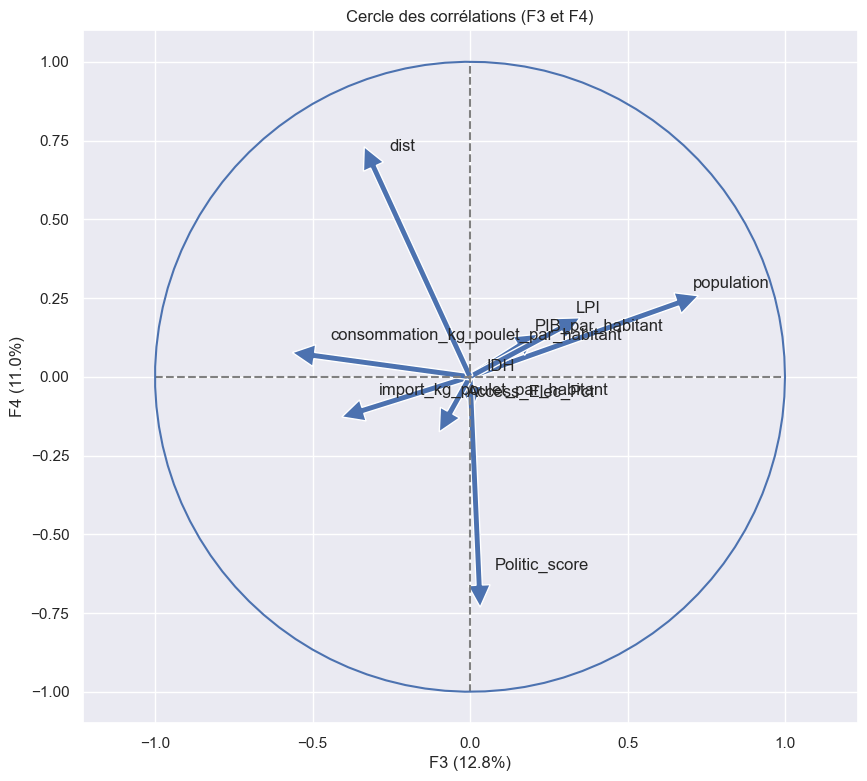

In [2213]:
correlation_graph(pca, (2,3), features)

Ici c'est très simple à analyser, sur F3, On a la taille du Pays et sur F4, on va retrouver la distance qui est anticorréelée à la stabilité politique. Raison de plus pour préféré les pays les plus proches.

## 3.6 Projection

Travaillons maintenant sur la projection de nos dimensions. Tout d'abord calculons les coordonnées de nos individus dans le nouvel espace :

In [2214]:
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[-2.83115651,  0.34337694,  0.23679191, -1.34035854, -0.18082892,
         0.31629939, -0.31901357,  1.07610971],
       [ 0.35166432,  0.95319969, -0.38373079,  0.95178121,  0.0165606 ,
        -0.67007219, -0.44067682, -1.06289287],
       [ 0.60401282, -0.76857513, -0.72038981, -0.74298582,  0.83113316,
         1.13264609,  0.62728196, -0.02005654],
       [-0.21699423, -0.83555818,  0.56249396, -0.1466893 , -0.69628876,
         1.71954431,  0.78564441, -0.11425732],
       [ 2.67190227, -0.66649617,  1.64877787, -0.47105518, -0.54939681,
        -0.32778154, -0.53974907, -0.28935814]])

Intéressant, mais il manque quelques éléments...

Essayons la version plus *élaborée* avec F1 et F2 :

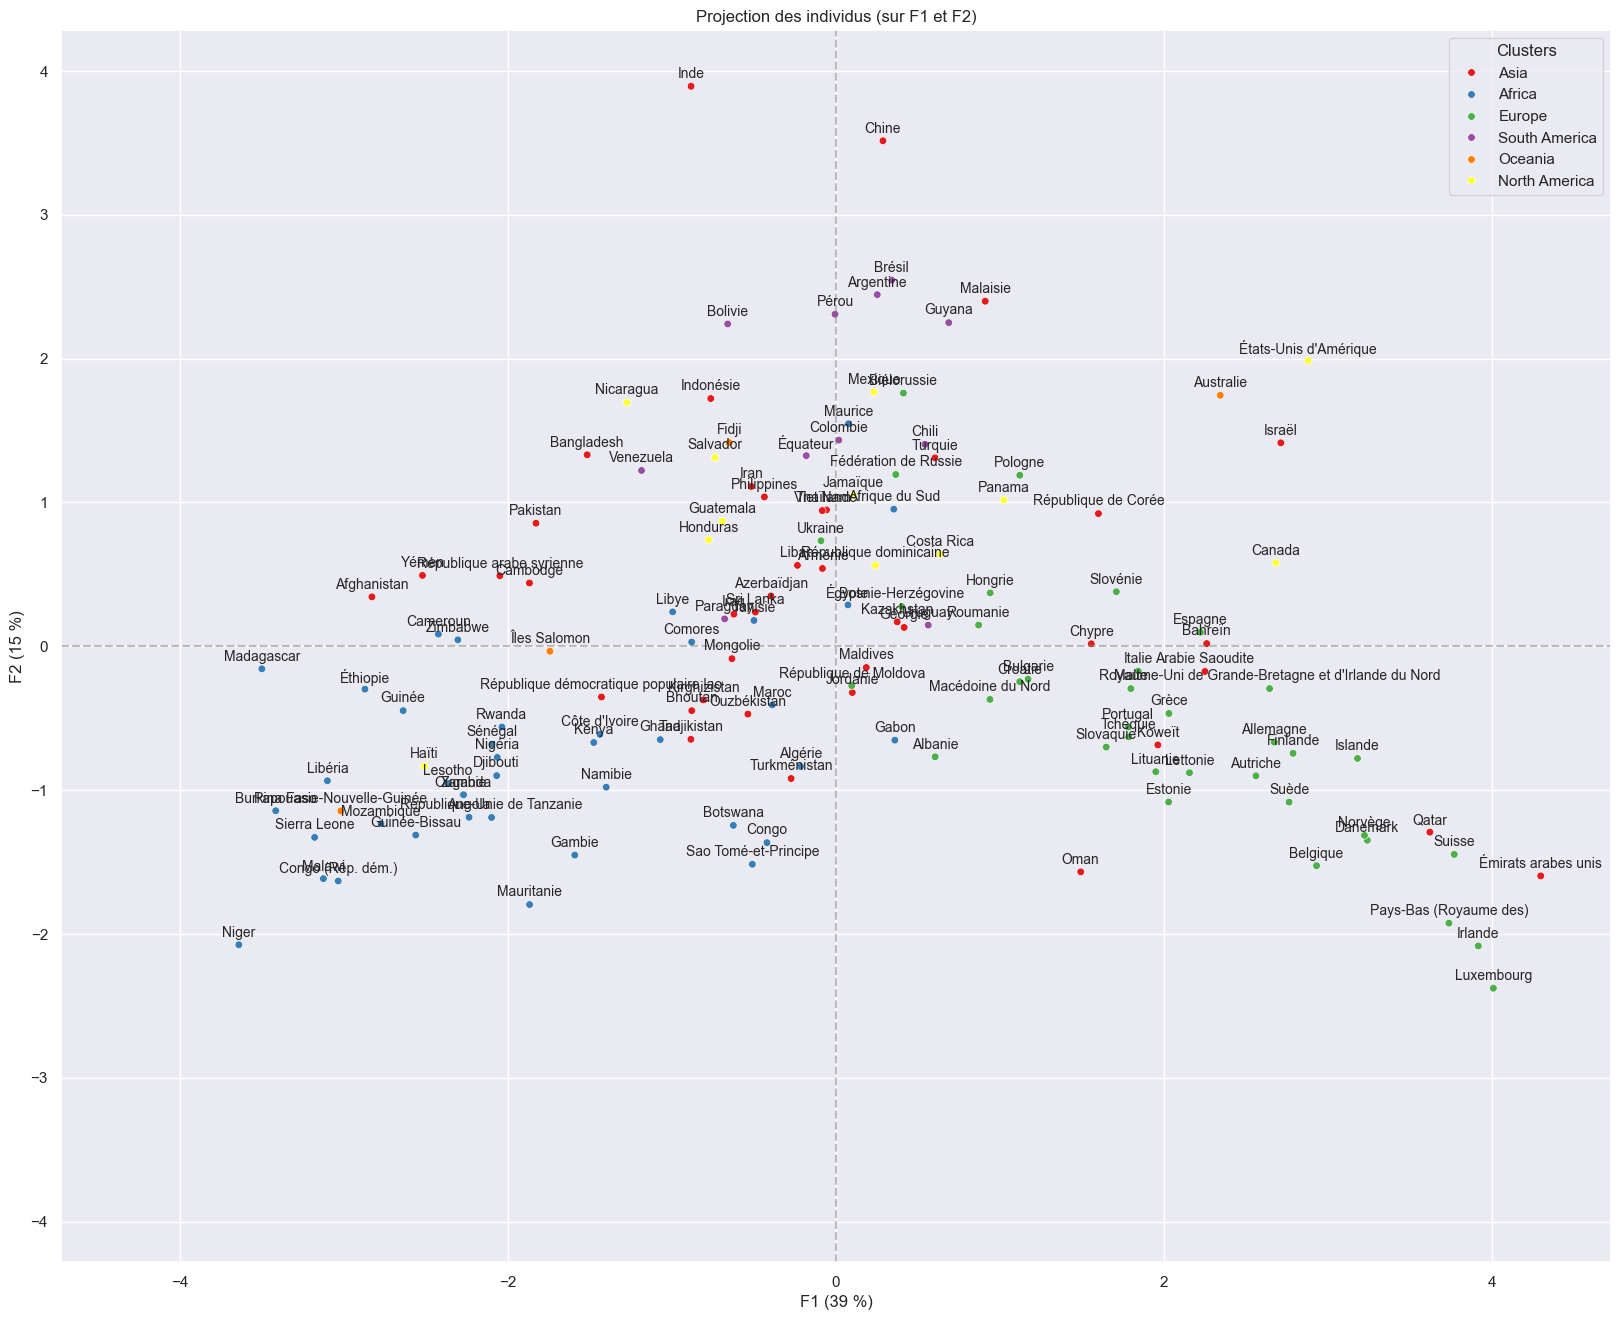

In [2215]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y, pca, labels=names, clusters=continents, figsize=(20,16), marker="o")

Sur F3 et F4

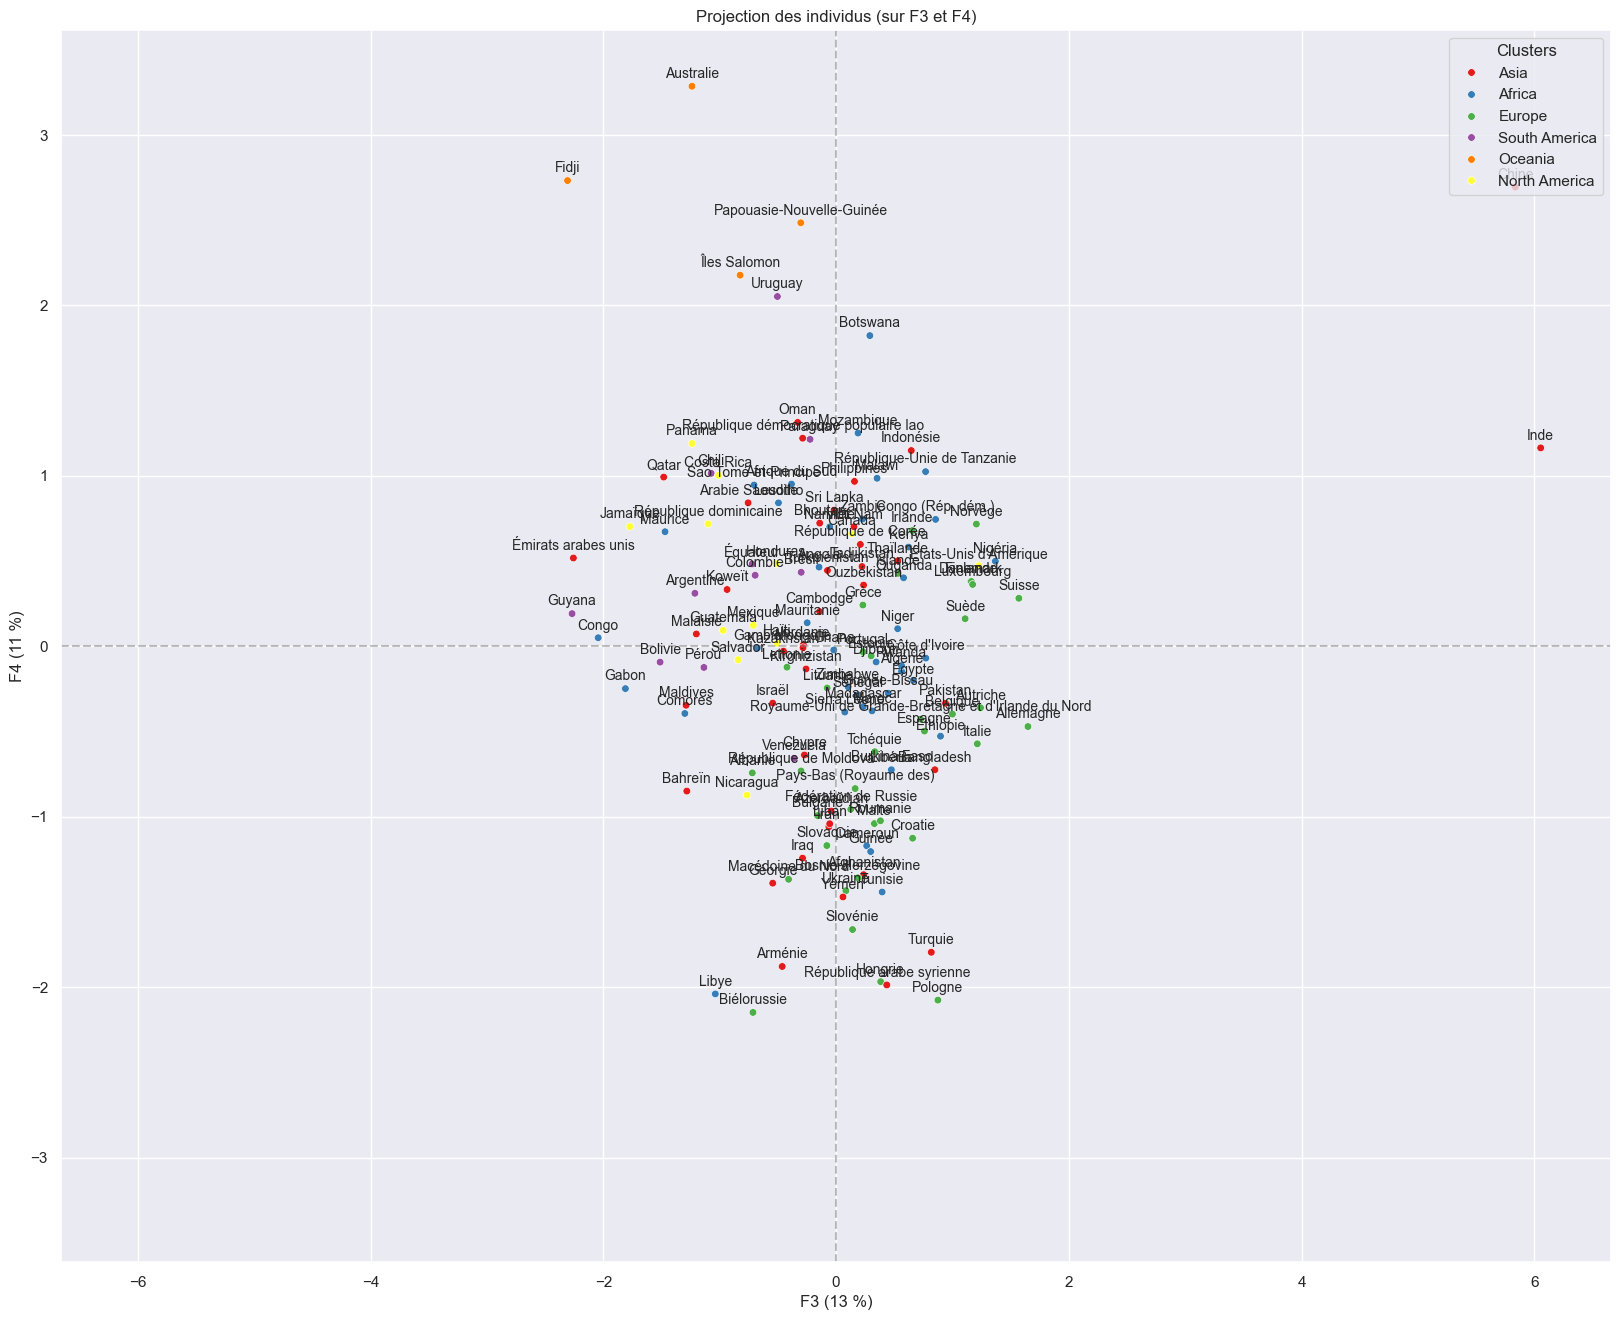

In [2216]:
x_y = [2,3]
display_factorial_planes(X_proj, x_y, pca, labels=names, clusters=continents, figsize=(20,16), marker="o")

# 4 CAH

Nous allons calculer les distances en spécifiant la méthode à utiliser:


In [2217]:
Z = linkage(X_scaled, method="ward")
Z[:10]

array([[ 29.        , 139.        ,   0.41124291,   2.        ],
       [ 94.        , 135.        ,   0.52471864,   2.        ],
       [ 95.        , 124.        ,   0.53171668,   2.        ],
       [ 71.        , 130.        ,   0.54293868,   2.        ],
       [  4.        ,  10.        ,   0.57192482,   2.        ],
       [101.        , 133.        ,   0.57422343,   2.        ],
       [ 99.        , 120.        ,   0.58025929,   2.        ],
       [ 46.        , 103.        ,   0.62605336,   2.        ],
       [ 39.        ,  74.        ,   0.63520307,   2.        ],
       [ 34.        , 106.        ,   0.66493011,   2.        ]])

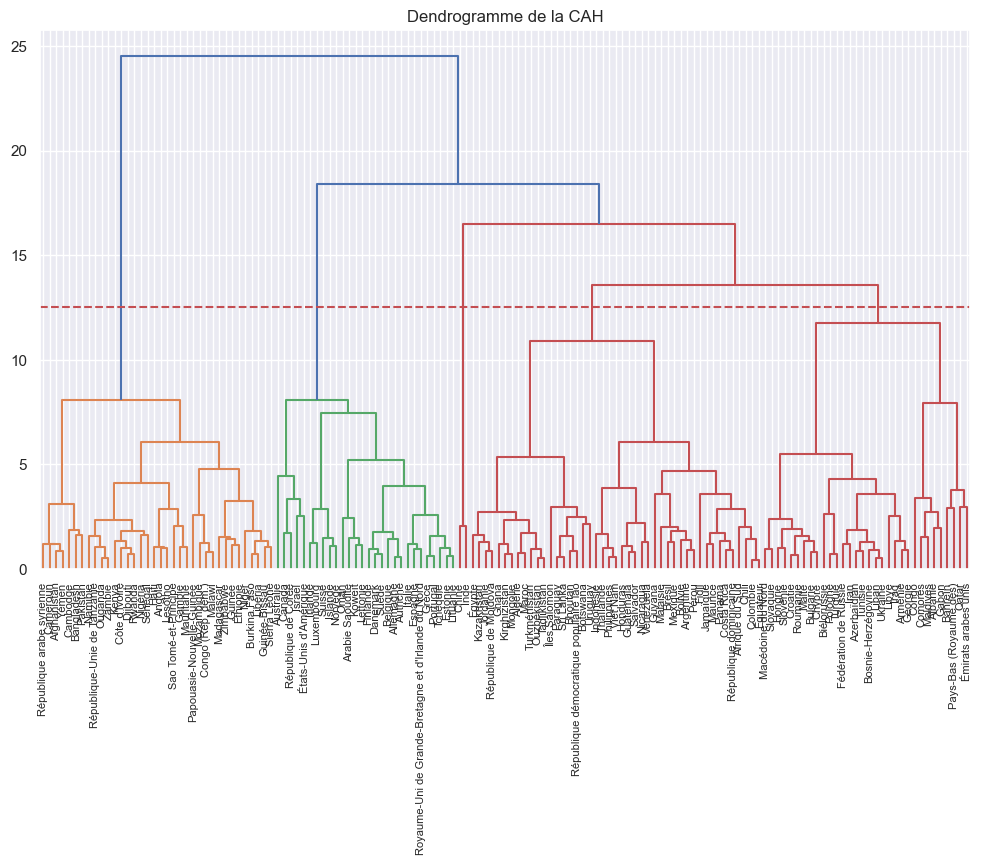

In [2218]:
# Affichage du dendrogramme
plt.figure(figsize=(12, 7))
dendrogram(Z, labels=names, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogramme de la CAH")
plt.axhline(y=12.5, color='r', linestyle='--') # Ligne de coupure imaginaire
plt.show()

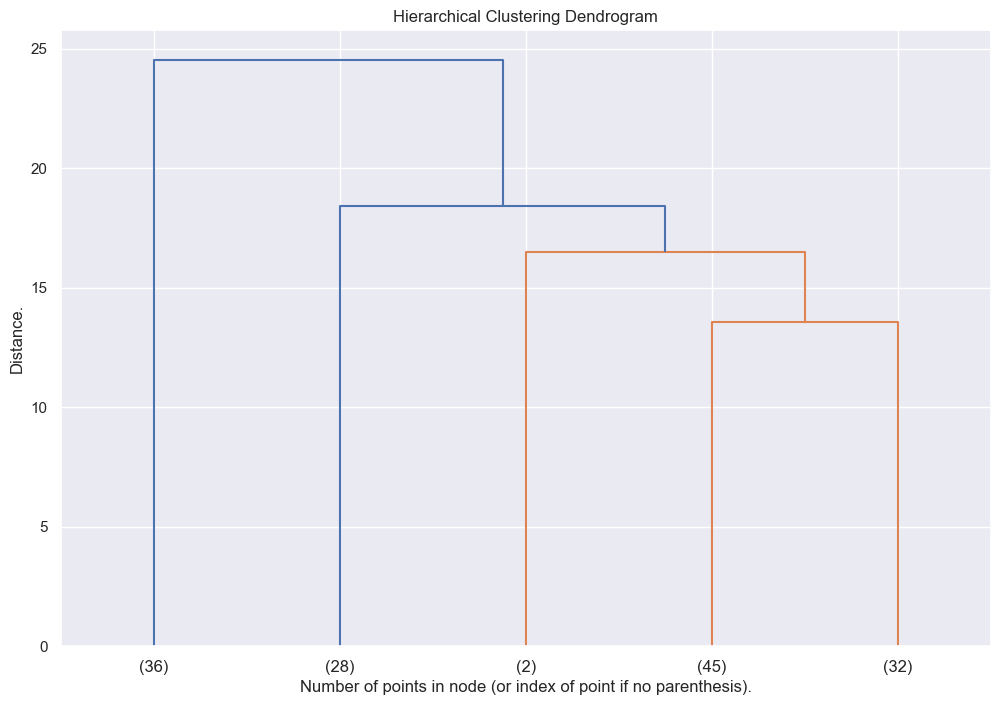

In [2219]:
# les arguments p=6, truncate_mode="lastp" signifient que l'on ne va afficher que 6 clusters

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

_ = dendrogram(Z, p=5, truncate_mode="lastp", ax=ax)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Distance.")
plt.show()

In [2220]:
k=5
clusters = fcluster(Z, k, criterion='maxclust')
clusters

array([1, 4, 5, 4, 2, 1, 2, 4, 5, 2, 2, 5, 5, 1, 2, 4, 5, 4, 5, 4, 4, 5,
       1, 1, 1, 2, 4, 3, 5, 4, 5, 5, 1, 4, 5, 1, 2, 1, 2, 2, 4, 2, 5, 5,
       1, 4, 2, 4, 1, 1, 4, 5, 1, 4, 5, 3, 4, 5, 5, 2, 2, 2, 2, 4, 4, 4,
       1, 4, 2, 1, 2, 5, 5, 1, 2, 2, 5, 1, 4, 1, 5, 5, 4, 4, 1, 4, 4, 1,
       1, 4, 1, 1, 2, 2, 1, 4, 1, 4, 1, 4, 5, 4, 5, 2, 4, 5, 5, 2, 1, 1,
       2, 4, 4, 4, 1, 4, 1, 1, 5, 5, 4, 2, 2, 1, 4, 2, 4, 5, 4, 5, 5, 4,
       4, 4, 1, 1, 1, 4, 5, 4, 2, 1, 4], dtype=int32)

Je vais essayer de voir si mes clusters correspondent aux continents.

Je compare mon array de clusters à ma série continents grace à crosstab

In [2221]:
crosstab = pd.crosstab(continents, clusters, dropna=False)
crosstab.rename_axis(columns="cluster", index="continents", inplace=True)
crosstab

cluster,1,2,3,4,5
continents,,,,,
Africa,28,0,0,7,5
Asia,6,5,2,15,12
Europe,0,20,0,1,15
North America,1,2,0,9,0
Oceania,1,1,0,2,0
South America,0,0,0,11,0


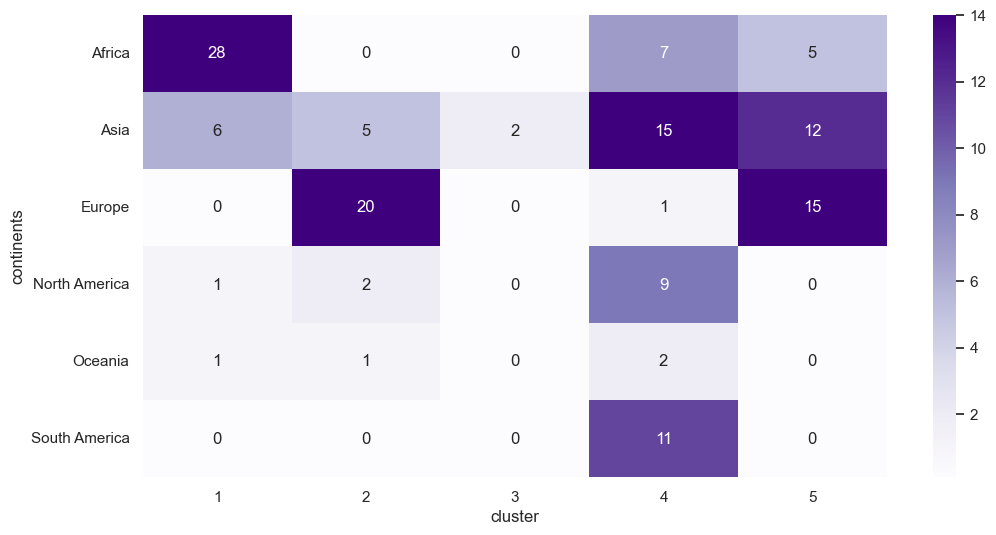

In [2222]:
fig, ax = plt.subplots(1,1, figsize=(12,6))
ax = sns.heatmap(crosstab, vmin=0.1, vmax=14, annot=True, cmap="Purples")

Cela ne fonctionne pas du tout. 

In [2223]:
df_x['cluster'] = clusters # on étiquette nos pays du df avec le cluster auquel ils appartiennent

In [2224]:
# Analyse des profils des clusters en faisant la moyenne des variables pour chaque cluster.
profil_clusters = df_x.groupby('cluster').mean(numeric_only=True) 
profil_clusters

,population,IDH,PIB_par_habitant,import_kg_poulet_par_habitant,Politic_score,Access_Elec_Pct,LPI,consommation_kg_poulet_par_habitant,dist
cluster,,,,,,,,,
1,4.281215e+07,0.548444,1526.381877,2.653248,0.502222,56.963889,2.458085,5.003060,6301.816583
2,3.125705e+07,0.927643,53989.952861,7.762092,-0.853286,100.000000,3.714286,25.274593,2832.928861
3,1.449786e+09,0.741000,7461.380200,0.692773,1.042000,99.750000,3.550000,7.706978,7409.731000
4,3.692868e+07,0.750667,7462.521383,2.919508,0.052289,97.680000,2.776000,25.256967,8210.691844
5,1.864128e+07,0.822125,17826.006217,14.150400,1.102094,97.137500,2.952137,24.159870,2995.198203


In [2225]:
# On crée un DataFrame temporaire des données scalées pour grouper facilement
df_scaled_tmp = pd.DataFrame(X_scaled)
df_scaled_tmp

,0,1,2,3,4,5,6,7,8
0,-0.065743,-1.732901,-0.707125,-0.715029,1.590086,-0.113889,-1.827161,-1.273267,0.025660
1,0.058506,-0.063149,-0.475026,-0.154622,0.043143,-0.004187,1.366165,0.938191,1.080532
2,-0.286418,0.407108,-0.383693,1.248263,-0.607606,0.558032,-0.762719,0.224384,-1.091912
3,-0.038849,0.086788,-0.500495,-0.728415,-1.273209,0.558032,-0.762719,-0.711509,-1.165675
4,0.180346,1.422590,1.502746,-0.052460,-0.164814,0.558032,2.075793,-0.576726,-1.418096
...,...,...,...,...,...,...,...,...,...
138,-0.241702,1.293099,1.285761,5.645630,-1.198232,0.558032,1.898386,1.772391,-0.069884
139,-0.199797,0.182202,-0.448681,-0.728211,0.308393,0.498611,-0.088572,0.786222,1.084329
140,1.658984,1.279468,2.633134,-0.708216,0.860823,0.558032,1.543572,1.864895,0.095115
141,0.432431,-1.726086,-0.671967,-0.728364,0.972582,-1.480586,-0.981343,-1.293065,0.023451


Je veux maintenant afficher mes centroides et mes clusters sur le premier plan factoriel

In [2226]:
# On crée un array pour nos centroids avec la moyenne de chaque cluster pour chaque variable
centroids_scaled = df_scaled_tmp.groupby(clusters).mean().values
centroids_scaled

array([[-5.79916299e-02, -1.37547553e+00, -6.60110582e-01,
        -4.20840807e-01,  1.87596224e-01, -1.40910187e+00,
        -8.37079337e-01, -9.89383940e-01,  2.25085677e-01],
       [-1.23978077e-01,  1.20888085e+00,  1.52195651e+00,
         1.71531507e-01, -7.71203055e-01,  5.58032439e-01,
         1.39150892e+00,  3.78014058e-01, -7.47294429e-01],
       [ 7.97665591e+00, -6.31488916e-02, -4.13261877e-01,
        -6.48158623e-01,  5.69400365e-01,  5.46605208e-01,
         1.10005455e+00, -8.06993599e-01,  5.35650337e-01],
       [-9.15897022e-02,  2.73248034e-03, -4.13214413e-01,
        -3.89967838e-01, -1.30657726e-01,  4.51987736e-01,
        -2.73075698e-01,  3.76825122e-01,  7.60171409e-01],
       [-1.96021574e-01,  4.89743484e-01,  1.78240925e-02,
         9.12258025e-01,  6.11906826e-01,  4.27190645e-01,
         3.94032411e-02,  3.02821404e-01, -7.01807952e-01]])

In [2227]:
# 2. On projette ces 5 centres dans l'ACP en utilisant la pca déjà entrainée
centroids_proj = pca.transform(centroids_scaled)
centroids_proj

array([[-2.34930939e+00, -7.06123580e-01,  2.74071342e-01,
         2.74724902e-03, -1.21881242e-02, -4.00344340e-01,
         1.67006061e-02,  4.25994907e-02],
       [ 2.55003798e+00, -5.32890373e-01,  4.82425483e-01,
         2.49963248e-01, -4.62479518e-01, -2.55292141e-01,
         6.65474596e-02,  1.15658399e-02],
       [-2.99618819e-01,  3.70436951e+00,  5.94640110e+00,
         1.92900649e+00,  3.60429216e+00,  4.65757978e-01,
         9.26346964e-01,  1.17390916e-01],
       [-2.57673012e-01,  7.05812520e-01, -5.21886667e-01,
         5.04929027e-01, -2.86998373e-01,  4.11225092e-01,
        -4.82792481e-02, -2.51030420e-02],
       [ 7.92768683e-01,  3.65961527e-02, -3.68199500e-01,
        -1.05242785e+00,  5.96704420e-01,  6.63728470e-02,
        -6.70212016e-02, -3.00803164e-02]])

In [2228]:
# On transforme notre X_proj en array
X_proj_arr = np.asarray(X_proj)
X_proj_arr

array([[-2.83115651,  0.34337694,  0.23679191, ...,  0.31629939,
        -0.31901357,  1.07610971],
       [ 0.35166432,  0.95319969, -0.38373079, ..., -0.67007219,
        -0.44067682, -1.06289287],
       [ 0.60401282, -0.76857513, -0.72038981, ...,  1.13264609,
         0.62728196, -0.02005654],
       ...,
       [ 2.87909264,  1.9861459 ,  1.22677062, ..., -1.83187616,
         0.72266448,  0.9030897 ],
       [-2.87351549, -0.2985428 ,  0.89719316, ..., -0.61678336,
        -0.02016302,  0.27615283],
       [-1.7454063 , -0.03507145, -0.82524614, ...,  0.16333441,
        -1.38613432,  0.25248158]], shape=(143, 8))

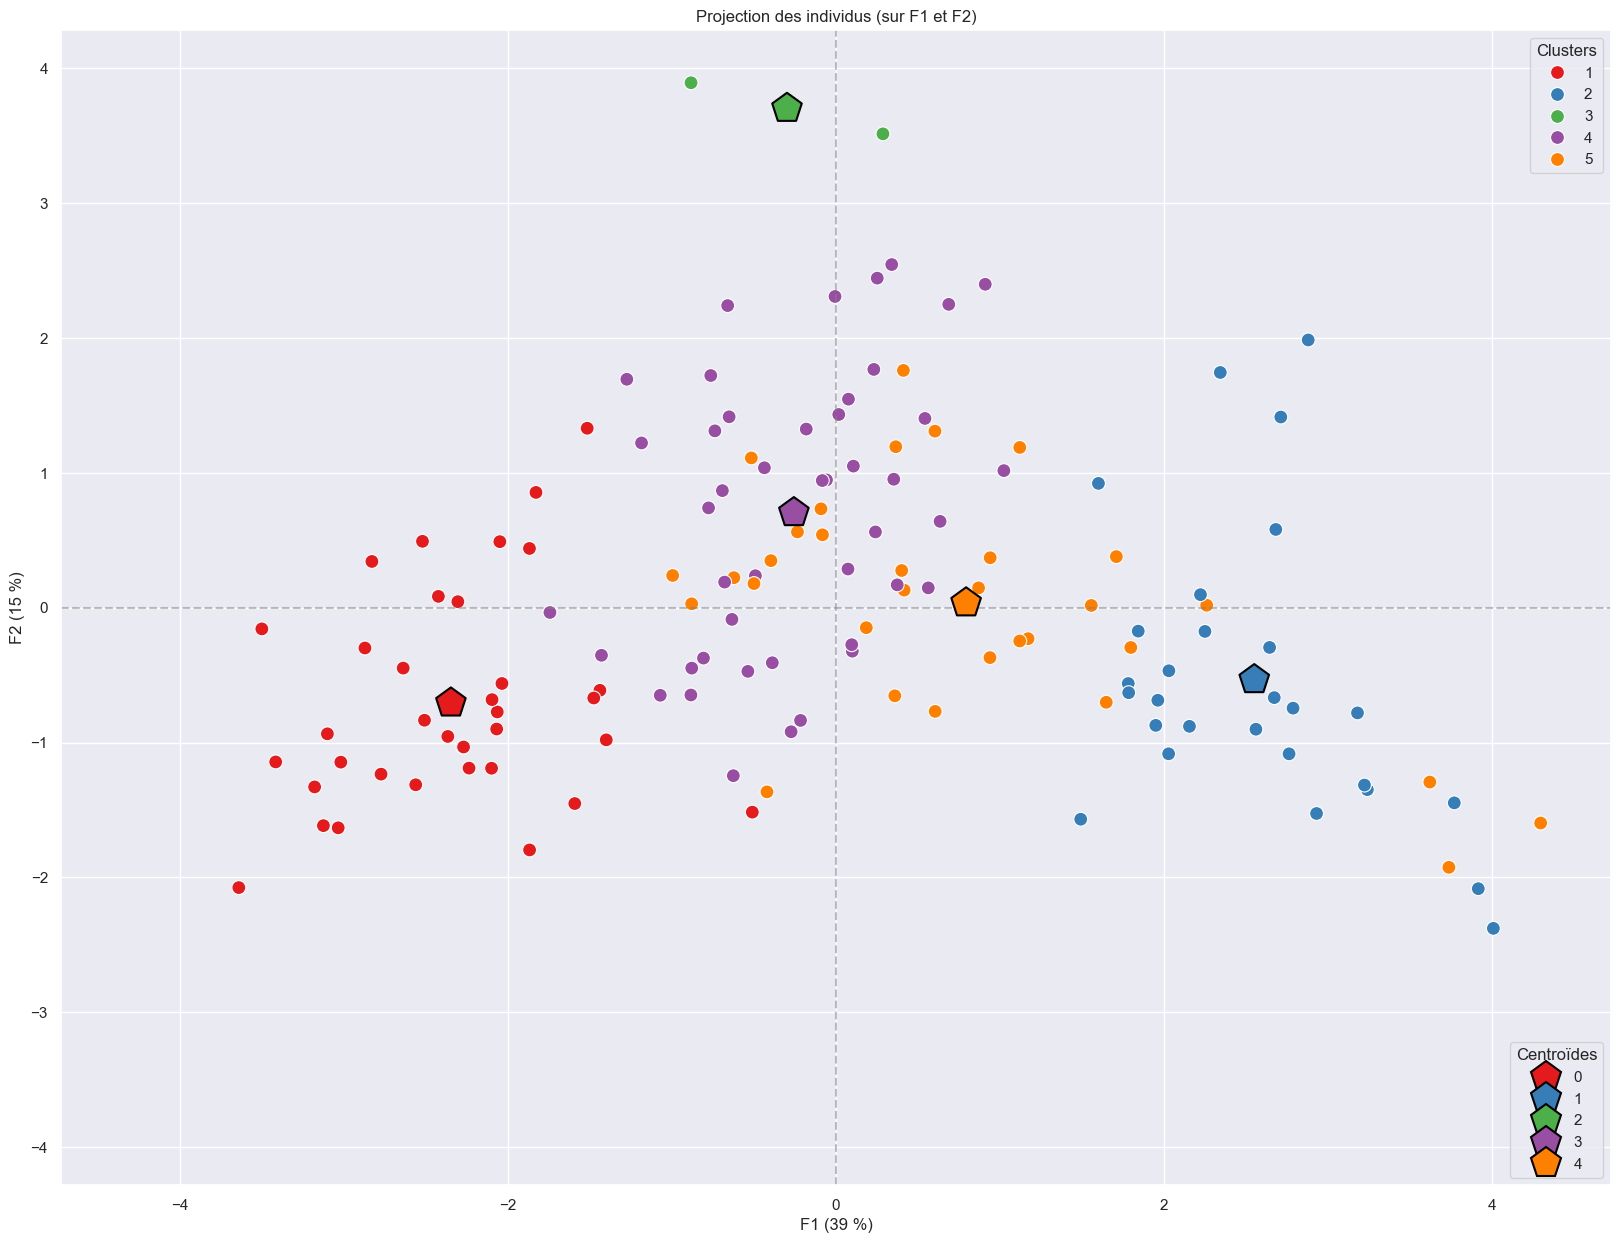

In [2229]:
display_factorial_planes(X_proj,  
                         x_y=(0,1), 
                         clusters=clusters,
                         pca=pca, 
                         figsize=(20,15), 
                         alpha=1,
                         marker='o',
                         s=100,
                         centroids=centroids_proj)

On voit clairement que nos clusters 2 et 5 sont les plus intéressants pour notre étude de marché.

# K-means

D'abord, décidons combien de clusters sont pertinents pour réduire au mieux l'inertie grâce à la méthode du coude ?

In [2230]:
# Une liste vide pour enregistrer les inerties :  
intertia_list = [ ]

# Notre liste de nombres de clusters : 
k_list = range(1, 10)
list(k_list)

# Pour chaque nombre de clusters : 
for i in k_list :
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(X) 
  intertia_list.append(kmeans.inertia_)

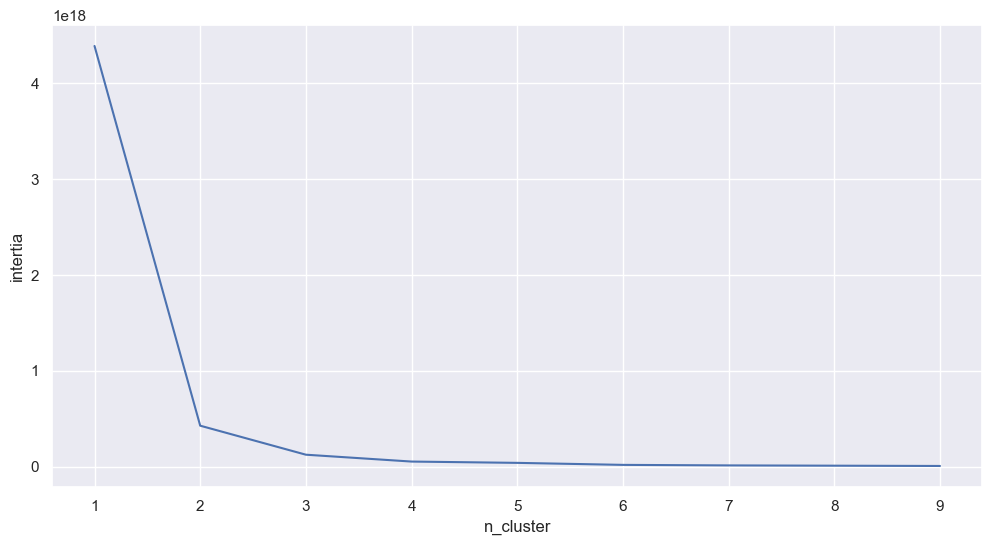

In [2231]:
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("intertia")
ax.set_xlabel("n_cluster")

ax = plt.plot(k_list, intertia_list)

2 clusters ont l'air d'être pertinents mais 3 seront plus utiles pour notre étude je pense.

Init and fit

In [2232]:
kmeans = KMeans(n_clusters=3)

In [2233]:
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Labels and centroids

In [2234]:
klusters = kmeans.labels_
klusters

array([2, 0, 0, 0, 1, 2, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       2, 0, 2, 1, 0, 0, 1, 0, 0, 2, 2, 0, 1, 2, 1, 2, 1, 1, 0, 1, 0, 0,
       2, 0, 1, 0, 2, 2, 0, 0, 2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       2, 0, 1, 2, 1, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 1, 0, 0, 2, 0, 0, 2,
       2, 0, 2, 2, 1, 1, 2, 0, 0, 0, 2, 0, 1, 0, 1, 1, 0, 1, 0, 1, 2, 2,
       1, 0, 0, 0, 2, 0, 0, 2, 1, 1, 0, 1, 1, 2, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 2, 2, 0, 1, 0, 1, 2, 0], dtype=int32)

Ici, l'étiquetage commence à 0 contrairement à celui de la CAH.

In [2235]:
centroids_scaled = kmeans.cluster_centers_
centroids_scaled

array([[ 0.15143944, -0.00279879, -0.41970724, -0.20027295,  0.16888429,
         0.44117658, -0.32927063,  0.23034897,  0.38397269],
       [-0.16612097,  1.14133325,  1.23990276,  0.60175596, -0.41236446,
         0.55803244,  1.23202805,  0.3740034 , -0.79807787],
       [-0.11025337, -1.41216808, -0.66291557, -0.32888365,  0.15920991,
        -1.61577316, -0.84222657, -0.94630965,  0.1886993 ]])

In [2236]:
df_centroids = pd.DataFrame(centroids_scaled, columns = features)
df_centroids

,population,IDH,PIB_par_habitant,import_kg_poulet_par_habitant,Politic_score,Access_Elec_Pct,LPI,consommation_kg_poulet_par_habitant,dist
0,0.151439,-0.002799,-0.419707,-0.200273,0.168884,0.441177,-0.329271,0.230349,0.383973
1,-0.166121,1.141333,1.239903,0.601756,-0.412364,0.558032,1.232028,0.374003,-0.798078
2,-0.110253,-1.412168,-0.662916,-0.328884,0.159210,-1.615773,-0.842227,-0.946310,0.188699


In [2237]:
df_x['kluster'] = klusters # on étiquette nos pays du df avec le cluster auquel ils appartiennent
# Analyse des profils des clusters en faisant la moyenne des variables pour chaque cluster.
profil_klusters = df_x.groupby('kluster').mean(numeric_only=True) 
profil_klusters

,population,IDH,PIB_par_habitant,import_kg_poulet_par_habitant,Politic_score,Access_Elec_Pct,LPI,consommation_kg_poulet_par_habitant,dist,cluster
kluster,,,,,,,,,,
0,7.948631e+07,0.749855,7306.414020,4.555509,0.475768,97.443478,2.744324,23.085474,6868.633203,4.057971
1,2.387727e+07,0.917732,47208.517437,11.472512,-0.345976,100.000000,3.624390,25.215136,2651.763039,2.951220
2,3.366043e+07,0.543061,1458.941425,3.446321,0.462091,52.442424,2.455184,5.641632,6172.011121,1.121212


In [2238]:
scaler = StandardScaler()

PCA + projection : nous allons faire une projection en utilisant une PCA

In [2239]:
pca = PCA(n_components=4) # On a déjà notre X_scaled de notre première PCA
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [2240]:
pca.explained_variance_ratio_.cumsum()

array([0.39170518, 0.5450584 , 0.67318276, 0.78317321])

On va visualiser notre variance expliquée par notre PCA. 55% sur le premier plan factoriel et 34% sur le deuxième.

Text(0, 0.5, '% of variance')

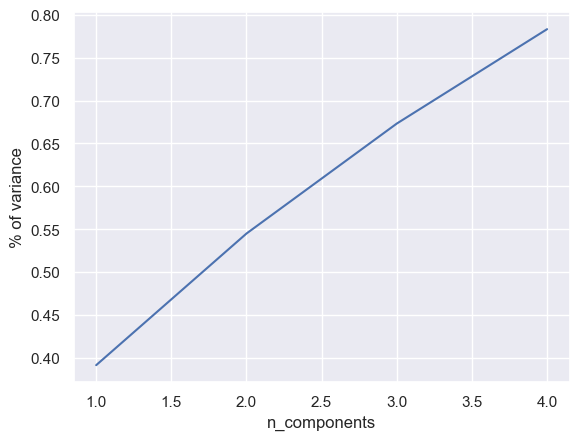

In [2241]:
plt.plot(range(1,5), pca.explained_variance_ratio_.cumsum())
plt.xlabel("n_components")
plt.ylabel("% of variance")

In [2242]:
X_proj = pca.transform(X_scaled) # On refait notre X_projeté avec la nouvelle PCA à 4 composantes.
X_proj[:10]

array([[-2.83115651,  0.34337694,  0.23679191, -1.34035854],
       [ 0.35166432,  0.95319969, -0.38373079,  0.95178121],
       [ 0.60401282, -0.76857513, -0.72038981, -0.74298582],
       [-0.21699423, -0.83555818,  0.56249396, -0.1466893 ],
       [ 2.67190227, -0.66649617,  1.64877787, -0.47105518],
       [-2.23864487, -1.1893426 , -0.14690325,  0.46426085],
       [ 2.24939915, -0.17546969, -0.75648741,  0.84159853],
       [ 0.25083509,  2.44474715, -1.21382295,  0.31080501],
       [-0.08343281,  0.54098892, -0.46340255, -1.87891584],
       [ 2.34289625,  1.74495064, -1.23926508,  3.28578843]])

In [2243]:
X_proj = pd.DataFrame(X_proj, columns = ["F1", "F2", "F3", "F4"]) #On la transforme en Dataframe pour plus de clarté.
X_proj[:10]

,F1,F2,F3,F4
0,-2.831157,0.343377,0.236792,-1.340359
1,0.351664,0.953200,-0.383731,0.951781
2,0.604013,-0.768575,-0.720390,-0.742986
3,-0.216994,-0.835558,0.562494,-0.146689
4,2.671902,-0.666496,1.648778,-0.471055
5,-2.238645,-1.189343,-0.146903,0.464261
6,2.249399,-0.175470,-0.756487,0.841599
7,0.250835,2.444747,-1.213823,0.310805
8,-0.083433,0.540989,-0.463403,-1.878916
9,2.342896,1.744951,-1.239265,3.285788


Il faut aussi projeter les centroids scalés sur le plan de l'ACP et les transformer en Dataframe pour plus de clarté.

In [2244]:
centroids_proj = pca.transform(centroids_scaled)
centroids_proj = pd.DataFrame(centroids_proj, 
                              columns = ["F1", "F2", "F3", "F4"], 
                              index=["cluster_0", "cluster_1", "cluster_2"])
centroids_proj

,F1,F2,F3,F4
cluster_0,-0.261548,0.688393,-0.246257,0.074765
cluster_1,2.373507,-0.478106,0.246647,-0.127258
cluster_2,-2.402028,-0.845355,0.208461,0.001782


Observons la représentation de nos 3 clusters en 3d avec les 3 premiers axes d'inertie.

In [2245]:
fig = px.scatter_3d(
    x=X_proj.iloc[:, 0], 
    y=X_proj.iloc[:, 1], 
    z=X_proj.iloc[:, 2],
    color=klusters,
    width=900,   # Largeur en pixels
    height=800   # Hauteur en pixels
)
fig.show()

Sur le premier plan factoriel

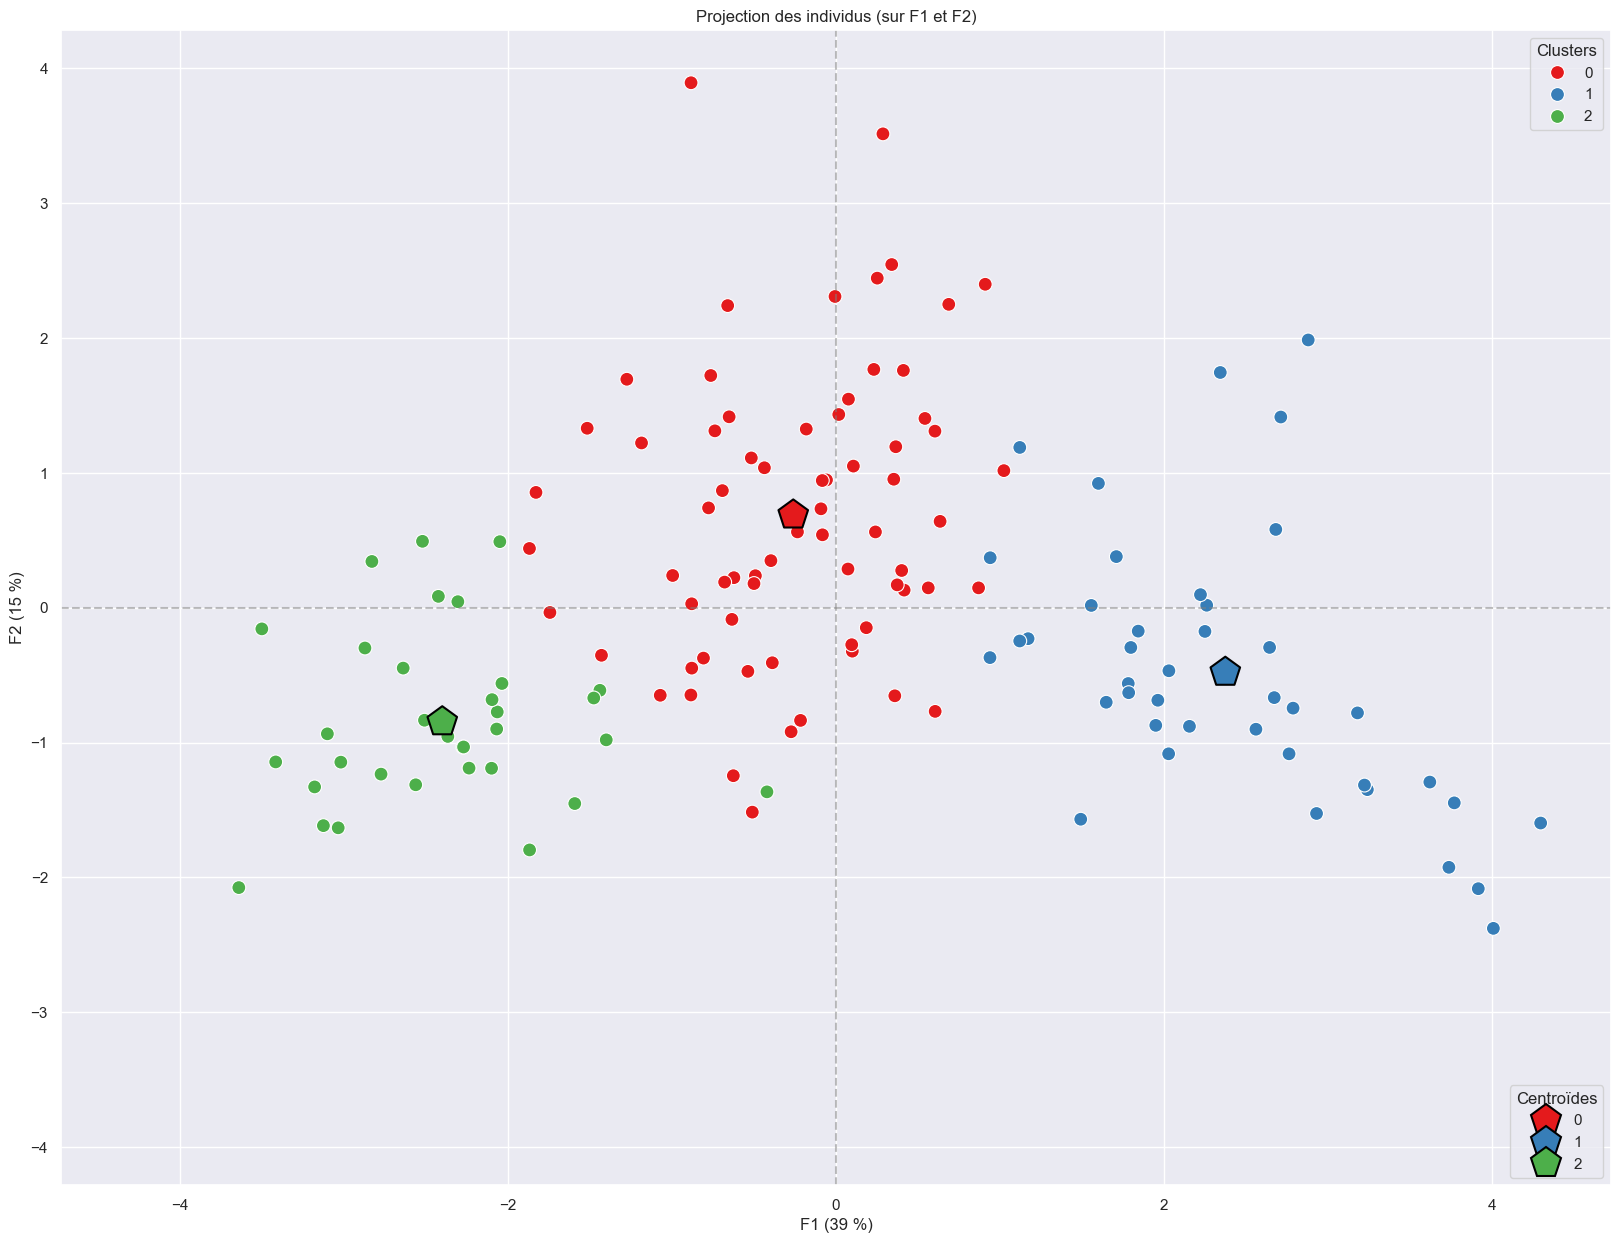

In [2246]:
display_factorial_planes(X_proj,  
                         x_y=(0,1), 
                         clusters=klusters,
                         pca=pca, 
                         figsize=(20,15), 
                         alpha=1,
                         marker='o',
                         s=100,
                         centroids=centroids_proj)

Avec les centroïdes

# Pays présents dans les 2 groupes les plus intéressants

In [2247]:
df_top_pays = df_x[(df_x['cluster'] == 2) & ((df_x['kluster'] == 1))]

In [2248]:
df_top_pays

,population,IDH,PIB_par_habitant,import_kg_poulet_par_habitant,Politic_score,Access_Elec_Pct,LPI,consommation_kg_poulet_par_habitant,dist,cluster,kluster
Pays,,,,,,,,,,,
Allemagne,84548231.0,0.959,53528.073268,5.830301,0.004,100.0,4.1,11.120669,439.8984,2,1
Arabie Saoudite,33264292.0,0.900,32093.963890,12.754671,-1.695,100.0,3.4,42.378845,4694.5000,2,1
Australie,26451124.0,0.958,67128.630651,0.007347,-1.158,100.0,3.7,51.236834,16975.4600,2,1
Autriche,9130429.0,0.930,56041.748295,6.223550,-0.237,100.0,4.0,11.626966,1035.1440,2,1
Belgique,11712893.0,0.951,55048.975235,15.624084,-0.747,100.0,4.0,9.532604,262.3845,2,1
Canada,39299105.0,0.939,54517.040894,4.106029,-0.058,100.0,4.0,37.748442,6004.6450,2,1
Danemark,5948136.0,0.962,68440.250913,6.552293,-1.645,100.0,4.1,16.500487,1027.6090,2,1
Espagne,47911579.0,0.918,33814.179553,3.020114,0.178,100.0,3.9,28.617318,1054.6560,2,1
Estonie,1367196.0,0.905,30201.408739,13.287583,-1.164,100.0,3.6,16.778604,1859.0910,2,1
